# GDV final analysis: attack patterns from the 2022 FIFA World Cup

## Project idea

I chose the 2022 World Cup data because I wanted the project to be close to football practice, not only to statistics. I play football myself and I am also interested in coaching, so I wanted to look for patterns that could still make sense for amateur training.

The main question is:

**Which simple attacking patterns from the 2022 FIFA World Cup can amateur coaches use as training ideas?**

The goal is not to copy professional teams directly. That would not be realistic for most amateur teams. I use the professional data more as a source of examples. I look at simple questions that can be discussed with players: How quickly does a team get into dangerous areas? How many passes happen before a shot? How does the ball enter the final third?

The analysis is guided by five smaller questions:

1. Do shots and goals happen more often after few passes or after longer passing sequences?
2. Which pass categories are common and which ones are efficient?
3. Which teams create shots often after entering the final third?
4. Which final third entry methods are relevant for dangerous attacks?
5. Which findings can be explained in a way that is useful for amateur coaches?

The analysis is descriptive. It does not prove a best tactic and it does not prove causality. It only shows patterns in the event data that can be used as realistic training ideas.

## 1. Setup

First I load the packages and define the project paths. I also set the colors in one place, so the figures stay consistent. I keep the color palette simple on purpose, because too many colors made earlier versions harder to read.

In [1]:
from pathlib import Path
import ast
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "GDV":
    PROJECT_ROOT = PROJECT_ROOT.parent

GDV_DIR = PROJECT_ROOT / "GDV"
DATA_DIR = GDV_DIR / "data"
FIGURE_DIR = GDV_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_ID = 43
SEASON_ID = 106

SHOT_SEQUENCES_FILE = DATA_DIR / "gdv_shot_sequences.csv"
ENTRY_POSSESSIONS_FILE = DATA_DIR / "gdv_final_third_entries.csv"
TEAM_SUMMARY_FILE = DATA_DIR / "gdv_team_attack_summary.csv"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#222222"
plt.rcParams["xtick.color"] = "#222222"
plt.rcParams["ytick.color"] = "#222222"
plt.rcParams["font.size"] = 10

COLORS = {
    "direct": "#2F6B9A",
    "medium2": "#E69F00",
    "medium": "#66A61E",
    "long": "#7570B3",
    "shot": "#4C78A8",
    "goal": "#E45756",
    "grey": "#D9D9D9",
    "dark": "#222222",
}

print("Project folder:", PROJECT_ROOT)

C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Project folder: c:\Users\tezca\Football


## 2. Helper functions

The raw data consists of single events such as passes, carries and shots. For this project I turn those events into simple measures that are easier to explain.

The most important measures are:

1. completed passes before a shot
2. start zone of an attack
3. entry into the final third
4. method of the final third entry
5. shot or goal after a final third entry

I keep the metrics simple. For an amateur coach, a clear measure is often more useful than a complicated model that is hard to explain.

In [2]:
def parse_location(value):
    if isinstance(value, list) and len(value) >= 2:
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) >= 2:
                return parsed
        except Exception:
            return None
    return None


def get_x(value):
    loc = parse_location(value)
    return loc[0] if isinstance(loc, list) else np.nan


def get_y(value):
    loc = parse_location(value)
    return loc[1] if isinstance(loc, list) else np.nan


def event_seconds(row):
    minute = 0 if pd.isna(row.get("minute")) else int(row.get("minute"))
    second = 0 if pd.isna(row.get("second")) else int(row.get("second"))
    return minute * 60 + second


def pass_category(n):
    if pd.isna(n):
        return np.nan
    n = int(n)
    if n <= 3:
        return "0-3"
    if n <= 6:
        return "4-6"
    if n <= 9:
        return "7-9"
    return "10+"

PASS_CATEGORY_ORDER = ["0-3", "4-6", "7-9", "10+"]

PASS_CATEGORY_COLORS = {
    "0-3": COLORS["direct"],
    "4-6": COLORS["medium"],
    "7-9": COLORS["long"],
    "10+": "#6B7280",
}


def start_zone(x):
    if pd.isna(x):
        return "Unknown"
    if x < 40:
        return "Defensive third"
    if x < 80:
        return "Middle third"
    return "Final third"


def is_completed_pass(row):
    if row.get("type") != "Pass":
        return False
    outcome = row.get("pass_outcome")
    return pd.isna(outcome) or str(outcome).lower() in ["nan", "none", ""]


def pass_distance(row):
    if pd.isna(row.get("x")) or pd.isna(row.get("y")) or pd.isna(row.get("end_x")) or pd.isna(row.get("end_y")):
        return np.nan
    return float(np.sqrt((row.get("end_x") - row.get("x")) ** 2 + (row.get("end_y") - row.get("y")) ** 2))


def entry_method(row):
    if row is None:
        return "No entry found"
    if row.get("type") in ["Carry", "Carry/Dribbling"]:
        return "Carry"
    if row.get("type") == "Pass":
        dist = pass_distance(row)
        if not pd.isna(dist) and dist >= 30:
            return "Long pass"
        return "Short pass"
    return "Other"


def extract_formation(value):
    if isinstance(value, dict):
        return value.get("formation")
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed.get("formation")
        except Exception:
            return np.nan
    return np.nan


def clean_label(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def contains_label(value, pattern):
    return pattern.lower() in clean_label(value).lower()


def shot_context(row):
    """Classify the context of a shot for transparent GDV reporting.

    Penalty shootouts are excluded from the main analysis. In-game penalties,
    free kicks and corners are kept, because they are relevant attacking
    situations for training, but they are explicitly labelled.
    """
    if int(row.get("period", 0) if not pd.isna(row.get("period", 0)) else 0) == 5:
        return "Penalty shootout"
    shot_type = clean_label(row.get("shot_type"))
    play_pattern = clean_label(row.get("play_pattern"))
    if "Penalty" in shot_type:
        return "Penalty"
    if "Free Kick" in shot_type or "Free Kick" in play_pattern:
        return "Free kick"
    if "Corner" in play_pattern:
        return "Corner"
    if "Throw In" in play_pattern:
        return "Throw in"
    return "Open play / other"


## 3. Data preparation

The notebook creates three working tables from the event data.

The first table contains all shots. For each shot, I count how many completed passes happened earlier in the same possession. This is useful because goals are rare, while shots give a broader picture of how teams create danger.

The second table contains final third entries. In this notebook, a final third entry happens when the ball is passed or carried from outside the final third into the area where `x >= 80`. After that, I check whether the same possession leads to a shot or goal.

The third table summarizes the team level measures. This makes it possible to compare teams and to see which teams are more direct or more effective after entering dangerous areas.

Penalty shootouts are excluded because they are not normal attacking possessions. Penalties, free kicks and corners during regular match play remain in the data, because they are still attacking situations. They are marked as shot context, so this limitation stays visible.

In [3]:
def prepare_events(events):
    needed_cols = [
        "id", "index", "period", "timestamp", "minute", "second", "team", "player", "type",
        "possession", "location", "pass_end_location", "carry_end_location", "pass_outcome",
        "shot_outcome", "shot_statsbomb_xg", "shot_type", "play_pattern", "tactics"
    ]
    for col in needed_cols:
        if col not in events.columns:
            events[col] = np.nan

    events = events.sort_values(["period", "index"]).copy()
    events["event_seconds"] = events.apply(event_seconds, axis=1)
    events["x"] = events["location"].apply(get_x)
    events["y"] = events["location"].apply(get_y)
    events["pass_end_x"] = events["pass_end_location"].apply(get_x)
    events["pass_end_y"] = events["pass_end_location"].apply(get_y)
    events["carry_end_x"] = events["carry_end_location"].apply(get_x)
    events["carry_end_y"] = events["carry_end_location"].apply(get_y)
    events["completed_pass"] = events.apply(is_completed_pass, axis=1)
    events["end_x"] = np.where(events["type"] == "Pass", events["pass_end_x"], events["carry_end_x"])
    events["end_y"] = np.where(events["type"] == "Pass", events["pass_end_y"], events["carry_end_y"])
    events["pass_distance"] = events.apply(pass_distance, axis=1)
    events["shot_context"] = events.apply(shot_context, axis=1)
    events["is_penalty_shootout"] = events["shot_context"].eq("Penalty shootout")
    events["is_standard_shot"] = events["shot_context"].isin(["Penalty", "Free kick", "Corner", "Throw in"])
    return events


def first_final_third_entry(group):
    candidates = group[
        (
            (group["type"].isin(["Pass", "Carry", "Carry/Dribbling"]))
            & (group["x"] < 80)
            & (group["end_x"] >= 80)
        )
    ].copy()
    pass_candidates = candidates[(candidates["type"] != "Pass") | (candidates["completed_pass"])]
    if pass_candidates.empty:
        return None
    return pass_candidates.sort_values("index").iloc[0]


def build_analysis_tables(force_rebuild=False):
    if (
        SHOT_SEQUENCES_FILE.exists()
        and ENTRY_POSSESSIONS_FILE.exists()
        and TEAM_SUMMARY_FILE.exists()
        and not force_rebuild
    ):
        shots = pd.read_csv(SHOT_SEQUENCES_FILE)
        entries = pd.read_csv(ENTRY_POSSESSIONS_FILE)
        team_summary = pd.read_csv(TEAM_SUMMARY_FILE)
        required_cols = {"period", "shot_type", "shot_context", "is_penalty_shootout"}
        if required_cols.issubset(set(shots.columns)):
            shots = shots[~shots["is_penalty_shootout"].astype(str).str.lower().isin(["true", "1", "yes"])].copy()
            return shots, entries, team_summary
        print("Cached files use an older schema. Rebuilding analysis tables to apply the set piece and shootout handling.")

    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
    shot_rows = []
    entry_rows = []
    formation_rows = []

    for match_nr, match in matches.reset_index(drop=True).iterrows():
        match_id = int(match["match_id"])
        match_label = f"{match['home_team']} vs {match['away_team']}"
        print(f"{match_nr + 1}/{len(matches)} {match_label}")

        try:
            events = sb.events(match_id=match_id)
        except Exception as exc:
            print("Could not load match", match_id, exc)
            continue

        events = prepare_events(events)
        # Period 5 contains penalty shootouts in StatsBomb football data. These are excluded
        # because they are not normal attacking possessions.
        events = events[~events["is_penalty_shootout"]].copy()

        starting_xi = events[events["type"] == "Starting XI"].copy()
        for _, row in starting_xi.iterrows():
            formation_rows.append({
                "match_id": match_id,
                "team": row.get("team"),
                "formation": extract_formation(row.get("tactics"))
            })

        formation_map = {
            (item["match_id"], item["team"]): item["formation"]
            for item in formation_rows
        }

        for (team, possession), group in events.groupby(["team", "possession"], dropna=True):
            if pd.isna(team) or pd.isna(possession):
                continue

            group = group.sort_values("index").copy()
            located = group.dropna(subset=["x", "y"])
            if located.empty:
                continue

            start_event = located.iloc[0]
            entry = first_final_third_entry(group)
            already_final_third = start_event["x"] >= 80

            if entry is not None:
                entry_index = entry["index"]
                entry_seconds = entry["event_seconds"]
                entry_x = entry["x"]
                entry_y = entry["y"]
                entry_end_x = entry["end_x"]
                entry_end_y = entry["end_y"]
                method = entry_method(entry)
                before_entry = group[group["index"] <= entry_index]
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(entry_seconds - start_event["event_seconds"])
            elif already_final_third:
                entry_index = start_event["index"]
                entry_seconds = start_event["event_seconds"]
                entry_x = start_event["x"]
                entry_y = start_event["y"]
                entry_end_x = start_event["x"]
                entry_end_y = start_event["y"]
                method = "Already in final third"
                passes_to_entry = 0
                time_to_entry = 0.0
            else:
                continue

            after_entry = group[group["index"] >= entry_index]
            shots_after_entry = after_entry[after_entry["type"] == "Shot"].copy()
            goals_after_entry = shots_after_entry[shots_after_entry["shot_outcome"].astype(str).str.lower() == "goal"]

            involved_players = group[group["index"] <= entry_index]["player"].dropna().nunique()

            entry_rows.append({
                "match_id": match_id,
                "match_label": match_label,
                "team": team,
                "possession": possession,
                "formation": formation_map.get((match_id, team), np.nan),
                "start_x": start_event["x"],
                "start_y": start_event["y"],
                "start_zone": start_zone(start_event["x"]),
                "entry_x": entry_x,
                "entry_y": entry_y,
                "entry_end_x": entry_end_x,
                "entry_end_y": entry_end_y,
                "entry_method": method,
                "passes_to_entry": passes_to_entry,
                "time_to_entry": time_to_entry,
                "fast_entry": bool(passes_to_entry <= 5 and time_to_entry <= 15),
                "players_before_entry": involved_players,
                "shot_after_entry": int(len(shots_after_entry) > 0),
                "goal_after_entry": int(len(goals_after_entry) > 0),
                "shot_count_after_entry": int(len(shots_after_entry)),
                "goal_count_after_entry": int(len(goals_after_entry)),
                "max_xg_after_entry": shots_after_entry["shot_statsbomb_xg"].max() if len(shots_after_entry) else 0,
                "xg_after_entry": shots_after_entry["shot_statsbomb_xg"].sum() if len(shots_after_entry) else 0,
            })

        shots = events[events["type"] == "Shot"].copy()
        for _, shot in shots.iterrows():
            team = shot.get("team")
            possession = shot.get("possession")
            shot_index = shot.get("index")
            if pd.isna(team) or pd.isna(possession) or pd.isna(shot_index):
                continue

            build = events[
                (events["team"] == team)
                & (events["possession"] == possession)
                & (events["index"] <= shot_index)
            ].sort_values("index").copy()

            located = build.dropna(subset=["x", "y"])
            if located.empty:
                continue

            first_event = located.iloc[0]
            completed_passes = build[build["completed_pass"]]
            players_involved = build["player"].dropna().nunique()
            entry = first_final_third_entry(build)

            if entry is not None:
                before_entry = build[build["index"] <= entry["index"]]
                entry_method_value = entry_method(entry)
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(entry["event_seconds"] - first_event["event_seconds"])
            elif first_event["x"] >= 80:
                entry_method_value = "Already in final third"
                passes_to_entry = 0
                time_to_entry = 0.0
            else:
                entry_method_value = "No entry found"
                passes_to_entry = np.nan
                time_to_entry = np.nan

            pass_count = int(len(completed_passes))
            duration = float(shot["event_seconds"] - first_event["event_seconds"])
            is_goal = str(shot.get("shot_outcome")).lower() == "goal"

            shot_rows.append({
                "match_id": match_id,
                "match_label": match_label,
                "team": team,
                "opponent": match["away_team"] if team == match["home_team"] else match["home_team"],
                "possession": possession,
                "formation": formation_map.get((match_id, team), np.nan),
                "player": shot.get("player"),
                "period": shot.get("period"),
                "minute": shot.get("minute"),
                "second": shot.get("second"),
                "shot_type": shot.get("shot_type"),
                "shot_context": shot.get("shot_context"),
                "is_penalty_shootout": bool(shot.get("is_penalty_shootout", False)),
                "is_standard_shot": bool(shot.get("is_standard_shot", False)),
                "shot_outcome": shot.get("shot_outcome"),
                "is_goal": int(is_goal),
                "shot_xg": shot.get("shot_statsbomb_xg") if not pd.isna(shot.get("shot_statsbomb_xg")) else 0,
                "play_pattern": shot.get("play_pattern"),
                "passes_before_shot": pass_count,
                "pass_category": pass_category(pass_count),
                "duration_seconds": duration,
                "players_involved": players_involved,
                "start_x": first_event["x"],
                "start_y": first_event["y"],
                "start_zone": start_zone(first_event["x"]),
                "shot_x": shot.get("x"),
                "shot_y": shot.get("y"),
                "entry_method": entry_method_value,
                "passes_to_entry": passes_to_entry,
                "time_to_entry": time_to_entry,
                "fast_entry_before_shot": bool((not pd.isna(passes_to_entry)) and passes_to_entry <= 5 and time_to_entry <= 15),
            })

        time.sleep(0.05)

    shots_df = pd.DataFrame(shot_rows)
    entries_df = pd.DataFrame(entry_rows)

    team_summary = (
        entries_df.groupby("team")
        .agg(
            entries=("team", "count"),
            fast_entries=("fast_entry", "sum"),
            shots_after_entry=("shot_after_entry", "sum"),
            goals_after_entry=("goal_after_entry", "sum"),
            avg_players_before_entry=("players_before_entry", "mean"),
        )
        .reset_index()
    )
    team_summary["fast_entry_share"] = team_summary["fast_entries"] / team_summary["entries"]
    team_summary["shot_rate_after_entry"] = team_summary["shots_after_entry"] / team_summary["entries"]
    team_summary["goal_rate_after_entry"] = team_summary["goals_after_entry"] / team_summary["entries"]

    goal_summary = (
        shots_df[shots_df["is_goal"] == 1]
        .groupby("team")
        .agg(
            goals=("is_goal", "sum"),
            avg_passes_before_goal=("passes_before_shot", "mean"),
            avg_goal_duration=("duration_seconds", "mean"),
        )
        .reset_index()
    )
    team_summary = team_summary.merge(goal_summary, on="team", how="left").fillna({"goals": 0})

    shots_df.to_csv(SHOT_SEQUENCES_FILE, index=False)
    entries_df.to_csv(ENTRY_POSSESSIONS_FILE, index=False)
    team_summary.to_csv(TEAM_SUMMARY_FILE, index=False)

    return shots_df, entries_df, team_summary

In [4]:
shots_df, entries_df, team_summary = build_analysis_tables(force_rebuild=False)

# Safety filter: penalty shootouts must not enter the main analysis.
if "is_penalty_shootout" in shots_df.columns:
    shots_df = shots_df[
        ~shots_df["is_penalty_shootout"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    ].copy()

if "shot_context" not in shots_df.columns:
    shots_df["shot_context"] = "Not available in cached file"

shots_df["passes_before_shot"] = pd.to_numeric(
    shots_df["passes_before_shot"],
    errors="coerce"
).fillna(0).astype(int)

shots_df["is_goal"] = pd.to_numeric(
    shots_df["is_goal"],
    errors="coerce"
).fillna(0).astype(int)

shots_df["pass_category"] = shots_df["passes_before_shot"].apply(pass_category)
shots_df["pass_category"] = pd.Categorical(
    shots_df["pass_category"],
    categories=PASS_CATEGORY_ORDER,
    ordered=True
)

if "goal_after_entry" in entries_df.columns:
    entries_df["goal_after_entry"] = pd.to_numeric(
        entries_df["goal_after_entry"],
        errors="coerce"
    ).fillna(0).astype(int)

if "shot_after_entry" in entries_df.columns:
    entries_df["shot_after_entry"] = pd.to_numeric(
        entries_df["shot_after_entry"],
        errors="coerce"
    ).fillna(0).astype(int)

if "fast_entry" in entries_df.columns:
    entries_df["fast_entry"] = entries_df["fast_entry"].astype(str).str.lower().isin(
        ["true", "1", "yes"]
    )


# Translate cached German labels if an older processed file is loaded.
ENTRY_METHOD_LABELS = {
    "Langer Pass": "Long pass",
    "Kurzer Pass": "Short pass",
    "Bereits im offensiven Drittel": "Already in final third",
    "Andere": "Other",
}
START_ZONE_LABELS = {
    "Defensives Drittel": "Defensive third",
    "Mittelfeld": "Middle third",
    "Offensives Drittel": "Final third",
}

for frame in [shots_df, entries_df]:
    if "entry_method" in frame.columns:
        frame["entry_method"] = frame["entry_method"].replace(ENTRY_METHOD_LABELS)
    if "start_zone" in frame.columns:
        frame["start_zone"] = frame["start_zone"].replace(START_ZONE_LABELS)

print("Analysed shots:", len(shots_df))
print("Analysed goals:", int(shots_df["is_goal"].sum()))
print("Analysed final third entries:", len(entries_df))
print("Teams:", shots_df["team"].nunique())

display(shots_df.head())
display(entries_df.head())

print("Shot context:")
display(
    shots_df["shot_context"]
    .value_counts(dropna=False)
    .rename_axis("shot_context")
    .reset_index(name="count")
)

Analysed shots: 1453
Analysed goals: 169
Analysed final third entries: 7456
Teams: 32


,match_id,match_label,team,opponent,possession,formation,player,period,minute,second,...,players_involved,start_x,start_y,start_zone,shot_x,shot_y,entry_method,passes_to_entry,time_to_entry,fast_entry_before_shot
0,3857276,Canada vs Morocco,Canada,Morocco,6,4411,Mark Anthony Kaye,1,2,5,...,4,69.3,13.7,Middle third,96.5,40.7,Short pass,2.0,3.0,True
1,3857276,Canada vs Morocco,Morocco,Canada,8,433,Hakim Ziyech,1,3,29,...,7,87.0,4.7,Final third,83.9,45.0,Already in final third,0.0,0.0,True
2,3857276,Canada vs Morocco,Morocco,Canada,16,433,Abdelhamid Sabiri,1,8,18,...,1,86.8,38.4,Final third,86.8,38.4,Already in final third,0.0,0.0,True
3,3857276,Canada vs Morocco,Morocco,Canada,17,433,Sofiane Boufal,1,9,9,...,2,120.0,80.0,Final third,107.0,48.3,Already in final third,0.0,0.0,True
4,3857276,Canada vs Morocco,Canada,Morocco,30,4411,Tajon Buchanan,1,14,7,...,4,16.1,69.7,Defensive third,113.3,34.9,Carry,3.0,8.0,True


,match_id,match_label,team,possession,formation,start_x,start_y,start_zone,entry_x,entry_y,...,passes_to_entry,time_to_entry,fast_entry,players_before_entry,shot_after_entry,goal_after_entry,shot_count_after_entry,goal_count_after_entry,max_xg_after_entry,xg_after_entry
0,3857276,Canada vs Morocco,Canada,6,4411,69.3,13.7,Middle third,77.3,35.9,...,2,3.0,True,2,1,0,1,0,0.038882,0.038882
1,3857276,Canada vs Morocco,Canada,25,4411,80.1,0.1,Final third,75.0,3.1,...,2,1.0,True,2,0,0,0,0,0.000000,0.000000
2,3857276,Canada vs Morocco,Canada,26,4411,102.5,71.2,Final third,102.5,71.2,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000
3,3857276,Canada vs Morocco,Canada,30,4411,16.1,69.7,Defensive third,70.0,74.7,...,3,8.0,True,3,1,0,1,0,0.279145,0.279145
4,3857276,Canada vs Morocco,Canada,31,4411,96.0,20.8,Final third,96.0,20.8,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000


Shot context:


,shot_context,count
0,Open play / other,624
1,Throw-in,298
2,Free kick,285
3,Corner,223
4,Penalty,23


## 4. Design approach

The final analysis follows a simple reading order: overview first, then efficiency, then team comparison, and finally one concrete team example with Spain.

For category comparisons I use bar charts, because values on a shared axis are easy to compare. For team rankings I use a sorted lollipop plot, because the order stays clear and the chart feels lighter than a large bar chart with many teams.

I only use pitch graphics when the location on the field is part of the message. An earlier version with many individual arrows looked interesting, but it did not answer the final research question clearly enough. That is why the final Spain plot is aggregated. It shows repeated final third entries and the chance quality that followed them.

The main design decision was to remove decorative plots and keep the figures that answer a clear question.

In [5]:
def add_value_labels(ax, fmt="{:.0f}", padding=0.01):
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * padding
    for patch in ax.patches:
        width = patch.get_width()
        if width <= 0:
            continue
        ax.text(
            width + offset,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=9,
            color=COLORS["dark"],
        )


def percent_text(value):
    return f"{value:.1%}"

def legend_above(ax, ncol=2):
    """Place a legend above the plot so it does not cover the data."""
    return ax.legend(
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=ncol,
        borderaxespad=0.0,
    )


def legend_below(ax, ncol=2):
    """Place a legend below the plot when the top area is already full."""
    return ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=ncol,
        borderaxespad=0.0,
    )


## 5. Passes before shots and goals

The first plot answers the basic question: do dangerous attacks happen more often after few passes or after many passes?

I compare both shots and goals by pass category. Looking only at goals would be too narrow, because goals are rare and can be influenced by finishing quality and luck. Shots give a wider view of how teams reach dangerous positions.

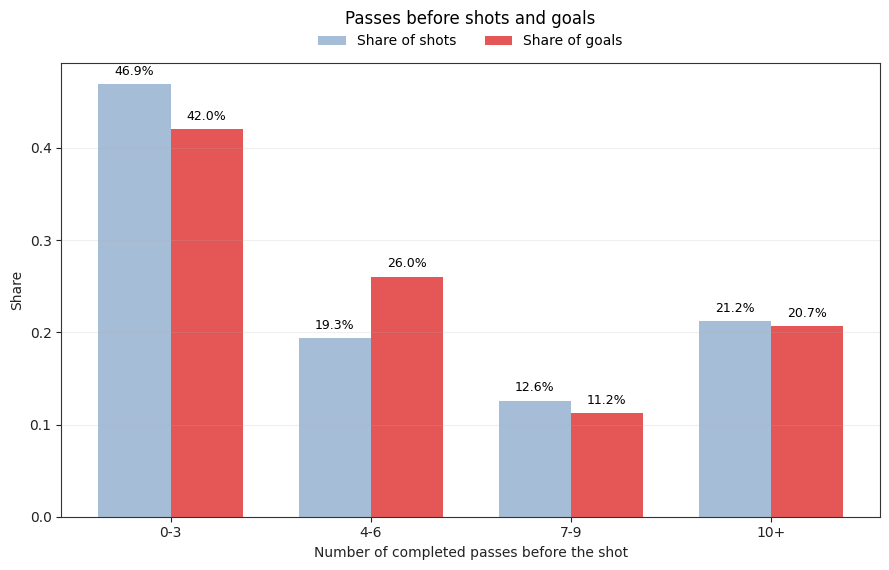

,shots,goals,shot_share,goal_share,conversion_rate
pass_category,,,,,
0-3,681,71,0.468685,0.420118,0.104258
4-6,281,44,0.193393,0.260355,0.156584
7-9,183,19,0.125946,0.112426,0.103825
10+,308,35,0.211975,0.207101,0.113636


In [6]:
category_summary = (
    shots_df.groupby("pass_category")
    .agg(shots=("pass_category", "count"), goals=("is_goal", "sum"))
    .reindex(PASS_CATEGORY_ORDER)
    .fillna(0)
)

category_summary["shot_share"] = category_summary["shots"] / category_summary["shots"].sum()
category_summary["goal_share"] = category_summary["goals"] / category_summary["goals"].sum()
category_summary["conversion_rate"] = category_summary["goals"] / category_summary["shots"]

fig, ax = plt.subplots(figsize=(9, 5.8))
x = np.arange(len(category_summary))
width = 0.36

ax.bar(
    x - width / 2,
    category_summary["shot_share"],
    width,
    label="Share of shots",
    color="#A6BDD7"
)

ax.bar(
    x + width / 2,
    category_summary["goal_share"],
    width,
    label="Share of goals",
    color=COLORS["goal"]
)

for i, row in enumerate(category_summary.itertuples()):
    ax.text(
        i - width / 2,
        row.shot_share + 0.01,
        percent_text(row.shot_share),
        ha="center",
        fontsize=9
    )
    ax.text(
        i + width / 2,
        row.goal_share + 0.01,
        percent_text(row.goal_share),
        ha="center",
        fontsize=9
    )

ax.set_title("Passes before shots and goals", pad=28)
ax.set_ylabel("Share")
ax.set_xlabel("Number of completed passes before the shot")
ax.set_xticks(x)
ax.set_xticklabels(category_summary.index)
legend_above(ax, ncol=2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_passes_before_shots_goals.png", dpi=300, bbox_inches="tight")
plt.show()

display(category_summary)


## 6. Efficiency by pass category

Frequency alone is not enough. A pass category can produce many shots, but still have a low goal conversion rate.

Here I calculate the goal conversion rate for each pass category. This helps separate volume from efficiency. For coaches, this difference matters because training should not only create many shots. It should create good shots.

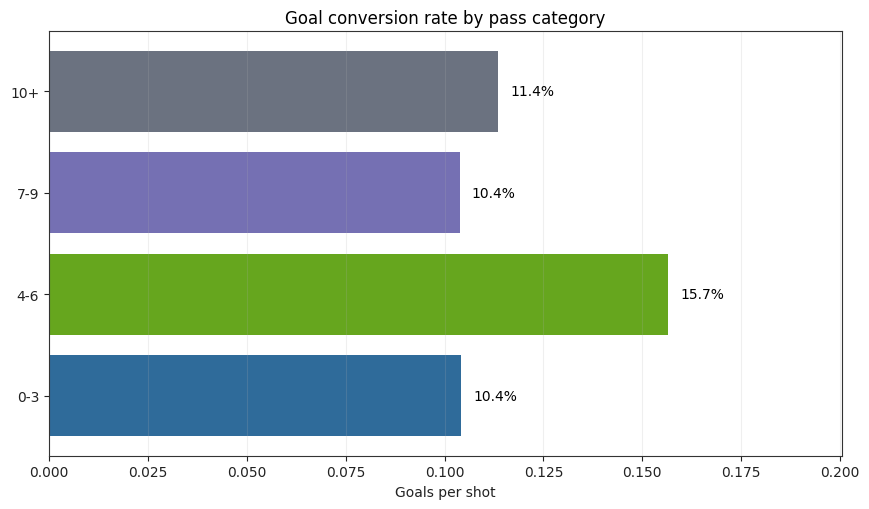

In [7]:
plot_data = category_summary.copy()
fig, ax = plt.subplots(figsize=(8.8, 5.2))

bars = ax.barh(
    plot_data.index,
    plot_data["conversion_rate"],
    color=[PASS_CATEGORY_COLORS.get(str(c), "#6B7280") for c in plot_data.index]
)

ax.set_title("Goal conversion rate by pass category")
ax.set_xlabel("Goals per shot")
ax.set_ylabel("")
ax.set_xlim(0, max(0.01, plot_data["conversion_rate"].fillna(0).max() * 1.28))
ax.grid(axis="x", alpha=0.2)

for bar, value in zip(bars, plot_data["conversion_rate"].fillna(0)):
    ax.text(
        value + 0.003,
        bar.get_y() + bar.get_height() / 2,
        percent_text(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_conversion_by_pass_category.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. What happens after entering the final third?

For training, the way into dangerous areas is very important. A team can have a lot of possession without creating danger. That is why I look at final third entries.

The plot shows teams that often create a shot after entering the final third. This is useful for coaching because it leads to simple training ideas: the first forward action after winning the ball, support after the entry, and an early shot option.

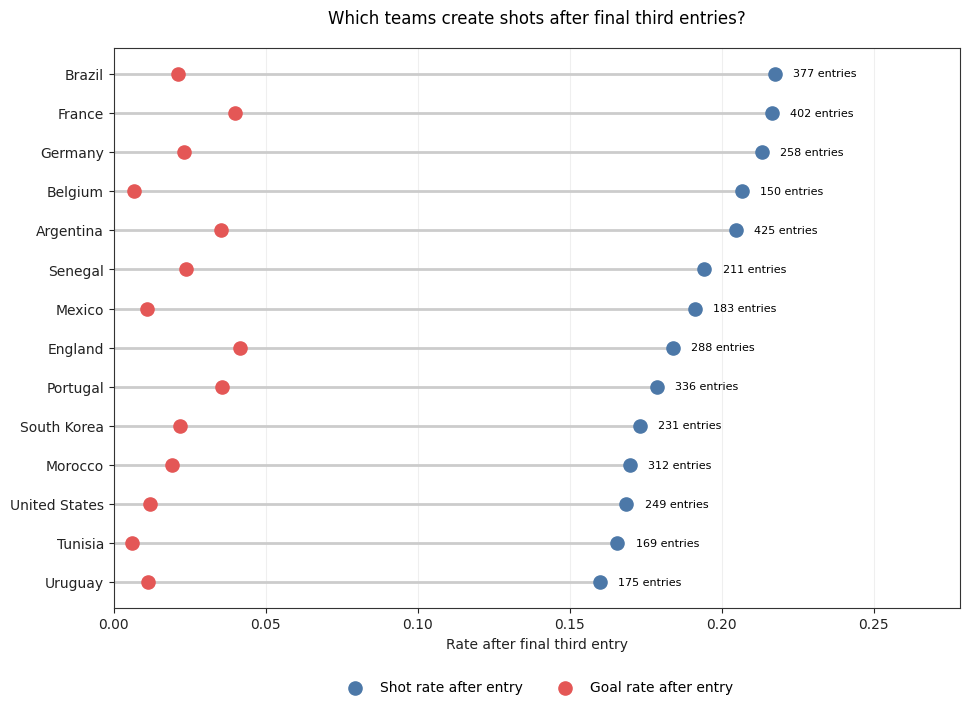

In [8]:
team_entry = team_summary[team_summary["entries"] >= 8].copy()
team_entry = team_entry.sort_values("shot_rate_after_entry", ascending=True).tail(14)

fig, ax = plt.subplots(figsize=(9.8, 7.2))
y = np.arange(len(team_entry))

ax.hlines(y, 0, team_entry["shot_rate_after_entry"], color="#CCCCCC", linewidth=2)
ax.scatter(
    team_entry["shot_rate_after_entry"],
    y,
    s=90,
    color=COLORS["shot"],
    label="Shot rate after entry",
    zorder=3
)
ax.scatter(
    team_entry["goal_rate_after_entry"],
    y,
    s=90,
    color=COLORS["goal"],
    label="Goal rate after entry",
    zorder=3
)

for i, row in enumerate(team_entry.itertuples()):
    ax.text(
        row.shot_rate_after_entry + 0.006,
        i,
        f"{row.entries:.0f} entries",
        va="center",
        fontsize=8
    )

ax.set_yticks(y)
ax.set_yticklabels(team_entry["team"])
ax.set_xlabel("Rate after final third entry")
ax.set_title("Which teams create shots after final third entries?", pad=18)
ax.set_xlim(0, max(team_entry["shot_rate_after_entry"].max() * 1.28, 0.1))
legend_below(ax, ncol=2)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_final_third_entry_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Method of final third entry

This part looks at how the ball enters the final third. I compare long passes, short passes, carries and situations where the possession already starts high.

This is practical because each method can become a training exercise. A team can train long passes behind the back line, short combinations through midfield, or carries into open space. The chart should still be read carefully. A higher rate in this dataset does not prove that one method is always better.

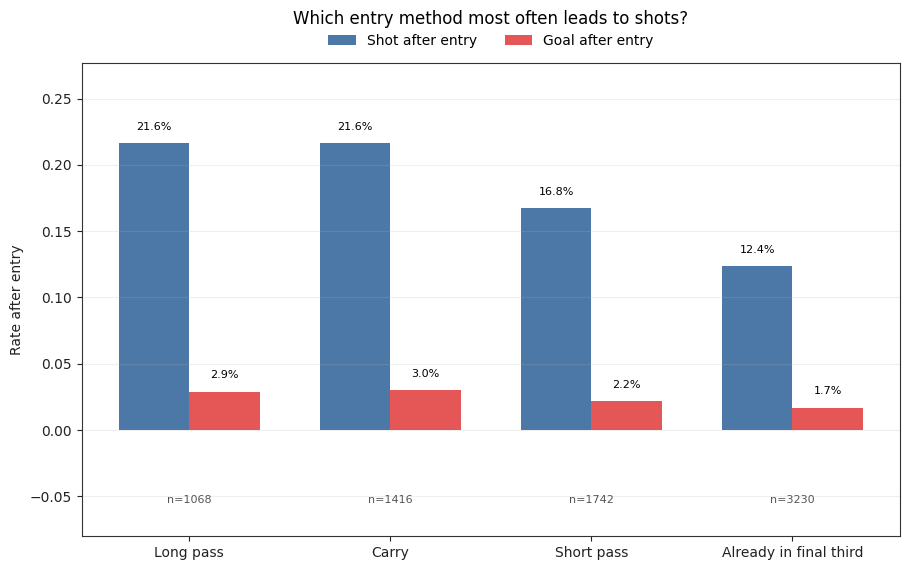

,entry_method,entries,shot_rate,goal_rate
2,Long pass,1068,0.216292,0.029026
1,Carry,1416,0.216102,0.030367
3,Short pass,1742,0.167623,0.021814
0,Already in final third,3230,0.123529,0.017028


In [9]:
method_summary = (
    entries_df.groupby("entry_method")
    .agg(
        entries=("entry_method", "count"),
        shot_rate=("shot_after_entry", "mean"),
        goal_rate=("goal_after_entry", "mean")
    )
    .reset_index()
)
method_summary = method_summary[method_summary["entries"] >= 10].sort_values("shot_rate", ascending=False)

fig, ax = plt.subplots(figsize=(9.2, 5.8))
x = np.arange(len(method_summary))
width = 0.35

ax.bar(
    x - width / 2,
    method_summary["shot_rate"],
    width,
    label="Shot after entry",
    color=COLORS["shot"]
)
ax.bar(
    x + width / 2,
    method_summary["goal_rate"],
    width,
    label="Goal after entry",
    color=COLORS["goal"]
)

for i, row in enumerate(method_summary.itertuples()):
    ax.text(i - width / 2, row.shot_rate + 0.01, percent_text(row.shot_rate), ha="center", fontsize=8)
    ax.text(i + width / 2, row.goal_rate + 0.01, percent_text(row.goal_rate), ha="center", fontsize=8)
    ax.text(i, -0.055, f"n={row.entries}", ha="center", fontsize=8, color="#555555")

ax.set_title("Which entry method most often leads to shots?", pad=28)
ax.set_ylabel("Rate after entry")
ax.set_xticks(x)
ax.set_xticklabels(method_summary["entry_method"], rotation=0)
ax.set_ylim(-0.08, max(method_summary["shot_rate"].max() * 1.28, 0.1))
legend_above(ax, ncol=2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_entry_method_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

display(method_summary)


## 9. Start zone of goal attacks

This plot shows where goal attacks start. Instead of using a detailed heatmap, I split the pitch into three simple zones: defensive third, middle third and final third.

This simplification is intentional. For a coach, the exact starting coordinate is usually less important than the broader question: did the goal come after a deep recovery, from midfield, or from a high starting point?

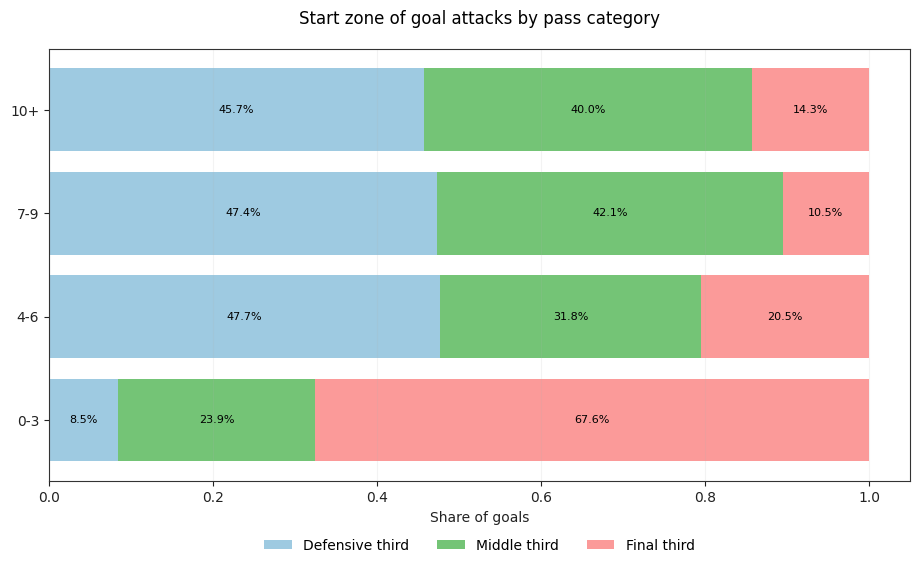

In [10]:
goals = shots_df[shots_df["is_goal"] == 1].copy()
start_matrix = (
    goals.groupby(["pass_category", "start_zone"])
    .size()
    .reset_index(name="count")
)
start_matrix["pass_category"] = pd.Categorical(
    start_matrix["pass_category"],
    categories=PASS_CATEGORY_ORDER,
    ordered=True
)
start_matrix = start_matrix.sort_values("pass_category")

pivot = start_matrix.pivot_table(
    index="pass_category",
    columns="start_zone",
    values="count",
    fill_value=0
)
zone_order = ["Defensive third", "Middle third", "Final third", "Unknown"]
pivot = pivot.reindex(PASS_CATEGORY_ORDER).fillna(0)
pivot = pivot[[c for c in zone_order if c in pivot.columns]]
share = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9.3, 5.8))
left = np.zeros(len(share))
zone_colors = {
    "Defensive third": "#9ECAE1",
    "Middle third": "#74C476",
    "Final third": "#FB9A99",
    "Unknown": "#CCCCCC",
}

for zone in share.columns:
    ax.barh(
        share.index,
        share[zone],
        left=left,
        label=zone,
        color=zone_colors.get(zone, "#CCCCCC")
    )
    for i, value in enumerate(share[zone]):
        if value > 0.08:
            ax.text(
                left[i] + value / 2,
                i,
                percent_text(value),
                ha="center",
                va="center",
                fontsize=8
            )
    left += share[zone].values

ax.set_title("Start zone of goal attacks by pass category", pad=18)
ax.set_xlabel("Share of goals")
ax.set_ylabel("")
legend_below(ax, ncol=min(3, len(share.columns)))
ax.grid(axis="x", alpha=0.15)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_goal_start_zone.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Team ranking: which teams scored more directly?

The team comparison makes the analysis easier to understand. For each team, I calculate the average number of completed passes before a goal.

I use a sorted lollipop plot because the ranking can be read quickly. The point size shows how many goals were included for each team. This is a small reminder that some team values are based on more goals than others.

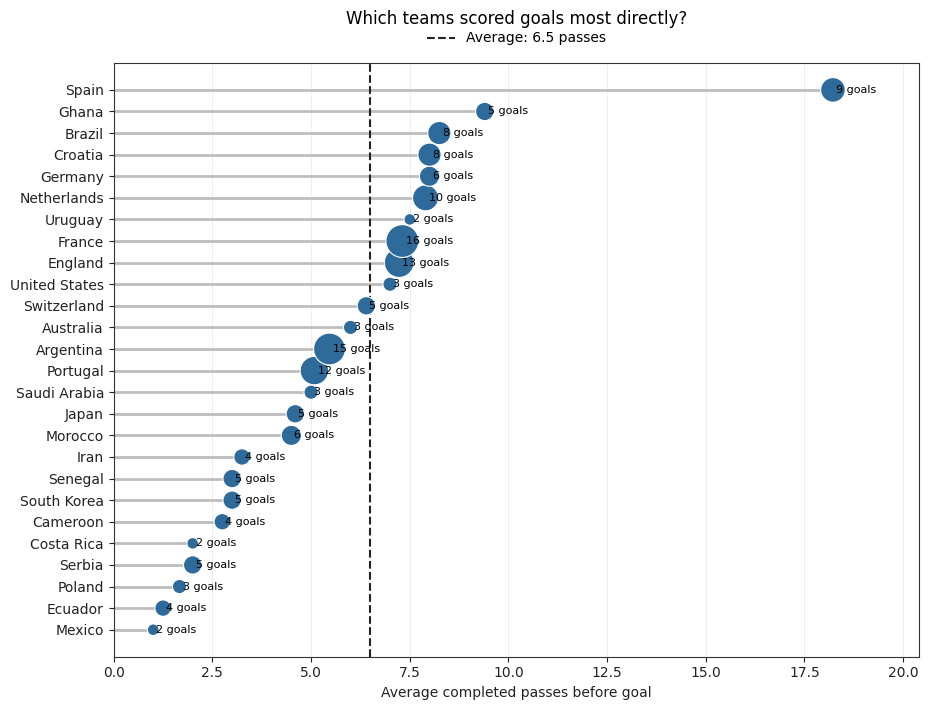

In [11]:
team_goals = (
    goals.groupby("team")
    .agg(
        goals=("is_goal", "sum"),
        avg_passes_before_goal=("passes_before_shot", "mean"),
        avg_duration=("duration_seconds", "mean")
    )
    .reset_index()
)
team_goals = team_goals[team_goals["goals"] >= 2].sort_values("avg_passes_before_goal", ascending=True)

fig, ax = plt.subplots(figsize=(9.4, 7.2))
y = np.arange(len(team_goals))

ax.hlines(y, 0, team_goals["avg_passes_before_goal"], color="#BDBDBD", linewidth=2)
ax.scatter(
    team_goals["avg_passes_before_goal"],
    y,
    s=team_goals["goals"] * 35,
    color=COLORS["direct"],
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

overall_avg = goals["passes_before_shot"].mean()
ax.axvline(
    overall_avg,
    color=COLORS["dark"],
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {overall_avg:.1f} passes"
)

for i, row in enumerate(team_goals.itertuples()):
    ax.text(
        row.avg_passes_before_goal + 0.08,
        i,
        f"{row.goals:.0f} goals",
        va="center",
        fontsize=8
    )

ax.set_yticks(y)
ax.set_yticklabels(team_goals["team"])
ax.set_xlabel("Average completed passes before goal")
ax.set_title("Which teams scored goals most directly?", pad=28)
ax.set_xlim(0, max(team_goals["avg_passes_before_goal"].max() * 1.12, overall_avg * 1.4))
legend_above(ax, ncol=1)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_team_directness_ranking.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Spain: final third entries by lane

A single goal sequence was too weak as a case study because it only showed one example. For the final version I use Spain as a concrete team case.

The plot shows through which lanes Spain entered the final third and what chance quality followed. The green lines connect each entry with the following shot. The green shaded areas show the total xG after entries from that lane. xG means expected goals. It estimates the chance that a shot becomes a goal based on similar shots.

This visualization fits the research question better than a single scene because it shows a repeated attacking pattern for a possession based team.

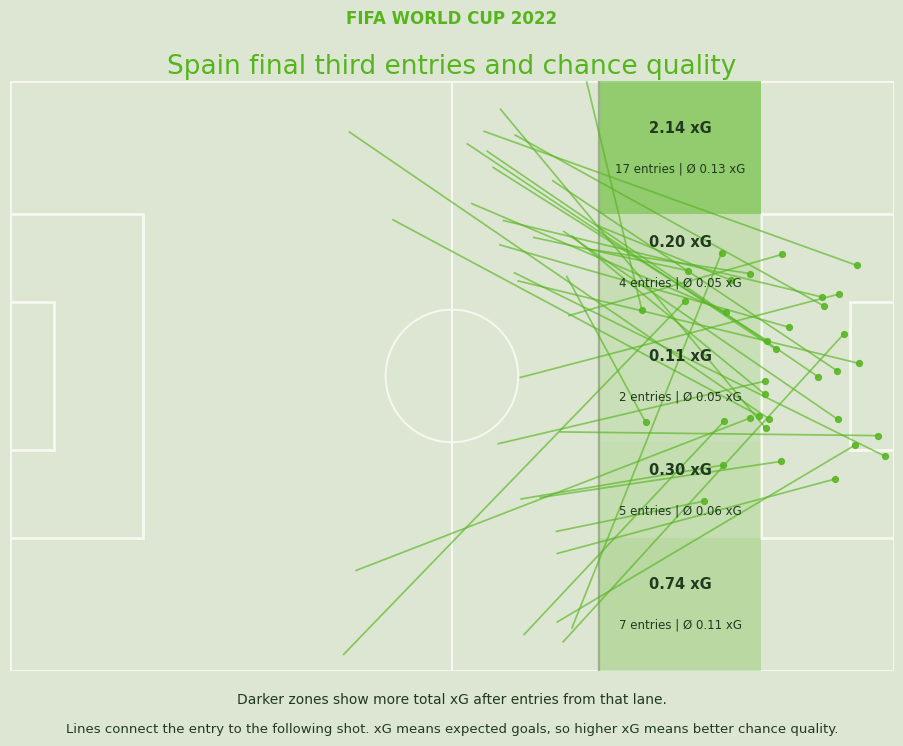

,entries,total_xg,avg_xg
lane,,,
Left wing,17,2.135902,0.125641
Left half space,4,0.200203,0.050051
Center,2,0.109851,0.054925
Right half space,5,0.301378,0.060276
Right wing,7,0.735057,0.105008


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc

team_name = "Spain"
competition_id = 43
season_id = 106

matches = sb.matches(competition_id=competition_id, season_id=season_id)
team_matches = matches[
    (matches["home_team"] == team_name) | (matches["away_team"] == team_name)
].copy()

def lane_name(y):
    if pd.isna(y):
        return np.nan
    if y < 18:
        return "Left wing"
    if y < 31:
        return "Left half space"
    if y < 49:
        return "Center"
    if y < 62:
        return "Right half space"
    return "Right wing"

lane_order = ["Left wing", "Left half space", "Center", "Right half space", "Right wing"]

lane_y = {
    "Left wing": (0, 18),
    "Left half space": (18, 31),
    "Center": (31, 49),
    "Right half space": (49, 62),
    "Right wing": (62, 80)
}

def collect_spain_entry_chances():
    rows = []

    for _, match in team_matches.iterrows():
        match_id = int(match["match_id"])
        events = sb.events(match_id=match_id)
        events = prepare_events(events).sort_values("index").copy()

        spain_events = events[events["team"] == team_name].copy()

        for possession_id, poss in spain_events.groupby("possession"):
            poss = poss.sort_values("index").copy()

            entries = poss[
                poss["type"].isin(["Pass", "Carry"])
                & poss["x"].notna()
                & poss["y"].notna()
                & poss["end_x"].notna()
                & poss["end_y"].notna()
                & (poss["x"] < 80)
                & (poss["end_x"] >= 80)
            ]

            if entries.empty:
                continue

            entry = entries.iloc[0]

            shots_after_entry = poss[
                (poss["type"] == "Shot")
                & poss["x"].notna()
                & poss["y"].notna()
                & (poss["index"] > entry["index"])
            ].copy()

            if shots_after_entry.empty:
                continue

            shot = shots_after_entry.iloc[0]

            shot_xg = shot.get("shot_xg", np.nan)
            if pd.isna(shot_xg):
                shot_xg = shot.get("shot_statsbomb_xg", np.nan)
            if pd.isna(shot_xg):
                shot_xg = 0.0

            rows.append({
                "match_id": match_id,
                "possession": possession_id,
                "entry_start_x": entry["x"],
                "entry_start_y": entry["y"],
                "entry_end_x": entry["end_x"],
                "entry_end_y": entry["end_y"],
                "shot_x": shot["x"],
                "shot_y": shot["y"],
                "shot_xg": float(shot_xg),
                "lane": lane_name(entry["end_y"])
            })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.dropna(subset=["lane"]).copy()
    return out

spain_entries = collect_spain_entry_chances()

if spain_entries.empty:
    raise ValueError("No Spain final third entries with a following shot were found.")

lane_summary = (
    spain_entries
    .groupby("lane")
    .agg(
        entries=("lane", "count"),
        total_xg=("shot_xg", "sum"),
        avg_xg=("shot_xg", "mean")
    )
    .reindex(lane_order)
    .fillna(0)
)

def draw_pitch(ax):
    bg = "#DDE6D2"
    line = "#F6F8F1"

    ax.set_facecolor(bg)
    ax.add_patch(Rectangle((0, 0), 120, 80, fill=False, edgecolor=line, linewidth=2))
    ax.plot([60, 60], [0, 80], color=line, linewidth=1.5)
    ax.add_patch(Arc((60, 40), 18, 18, theta1=0, theta2=360, color=line, linewidth=1.4))

    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))

    ax.axvline(80, color="#9CAE8D", linewidth=1.6)

    ax.set_xlim(0, 120)
    ax.set_ylim(80, 0)
    ax.set_aspect("equal")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor="#DDE6D2")
draw_pitch(ax)

green = "#56B51F"
dark = "#203A1F"
max_xg = max(lane_summary["total_xg"].max(), 0.01)

for lane in lane_order:
    y0, y1 = lane_y[lane]
    total_xg = lane_summary.loc[lane, "total_xg"]
    entries = int(lane_summary.loc[lane, "entries"])
    avg_xg = lane_summary.loc[lane, "avg_xg"]
    alpha = 0.12 + 0.43 * (total_xg / max_xg)

    ax.add_patch(
        Rectangle(
            (80, y0),
            22,
            y1 - y0,
            facecolor=green,
            edgecolor="none",
            alpha=alpha
        )
    )

    y_mid = (y0 + y1) / 2
    ax.text(
        91,
        y_mid - 2.7,
        f"{total_xg:.2f} xG",
        ha="center",
        va="center",
        fontsize=10.5,
        color=dark,
        fontweight="bold"
    )
    ax.text(
        91,
        y_mid + 2.8,
        f"{entries} entries | Ø {avg_xg:.2f} xG",
        ha="center",
        va="center",
        fontsize=8.5,
        color=dark
    )

# Keep the lines slightly transparent so the pitch stays readable.
for _, row in spain_entries.iterrows():
    ax.plot(
        [row["entry_start_x"], row["shot_x"]],
        [row["entry_start_y"], row["shot_y"]],
        color=green,
        linewidth=1.25,
        alpha=0.65
    )
    ax.scatter(row["shot_x"], row["shot_y"], s=18, color=green, alpha=0.85)

ax.text(
    60,
    -8.5,
    "FIFA WORLD CUP 2022",
    ha="center",
    va="center",
    fontsize=12,
    color=green,
    fontweight="bold"
)

ax.text(
    60,
    -2,
    "Spain final third entries and chance quality",
    ha="center",
    va="center",
    fontsize=19,
    color=green
)

ax.text(
    60,
    84,
    "Darker zones show more total xG after entries from that lane.",
    ha="center",
    va="center",
    fontsize=10,
    color=dark
)

ax.text(
    60,
    88,
    "Lines connect the entry to the following shot. xG means expected goals, so higher xG means better chance quality.",
    ha="center",
    va="center",
    fontsize=9.5,
    color=dark
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_spain_final_third_entries_for.png", dpi=300, bbox_inches="tight")
plt.show()

display(lane_summary)


## 12. Formation as context

Formation is only used as additional context. I do not use it as main evidence because event data does not show the full team shape away from the ball.

If enough formation data is available, the plot shows which formations were linked with more shots or goals after final third entries. The interpretation stays cautious and descriptive.

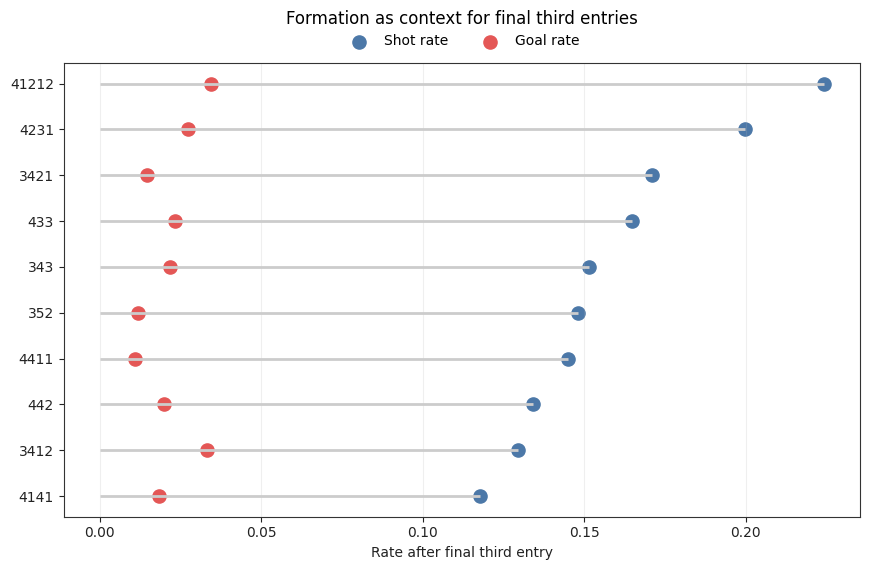

,formation,entries,fast_entry_share,shot_rate,goal_rate
6,4141,272,0.790441,0.117647,0.018382
4,3412,363,0.719008,0.129477,0.033058
3,442,903,0.829457,0.133998,0.019934
8,4411,276,0.807971,0.144928,0.010870
1,352,601,0.801997,0.148087,0.011647
0,343,370,0.816216,0.151351,0.021622
2,433,2265,0.743929,0.164680,0.023400
5,3421,415,0.855422,0.171084,0.014458
7,4231,1933,0.773927,0.199690,0.027419
9,41212,58,0.810345,0.224138,0.034483


In [13]:
formation_data = entries_df.dropna(subset=["formation"]).copy()
formation_profile = (
    formation_data.groupby("formation")
    .agg(
        entries=("formation", "count"),
        fast_entry_share=("fast_entry", "mean"),
        shot_rate=("shot_after_entry", "mean"),
        goal_rate=("goal_after_entry", "mean")
    )
    .reset_index()
)
formation_profile = formation_profile[formation_profile["entries"] >= 15].sort_values("shot_rate", ascending=True)

if not formation_profile.empty:
    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    y = np.arange(len(formation_profile))
    ax.hlines(y, 0, formation_profile["shot_rate"], color="#CCCCCC", linewidth=2)
    ax.scatter(formation_profile["shot_rate"], y, s=90, color=COLORS["shot"], label="Shot rate")
    ax.scatter(formation_profile["goal_rate"], y, s=90, color=COLORS["goal"], label="Goal rate")
    ax.set_yticks(y)
    ax.set_yticklabels(formation_profile["formation"].astype(str))
    ax.set_xlabel("Rate after final third entry")
    ax.set_title("Formation as context for final third entries", pad=28)
    legend_above(ax, ncol=2)
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "08_formation_context.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("There is not enough formation data for a stable formation plot.")

display(formation_profile)


## 13. Evaluation and iteration

For GDV it is not enough to show finished plots. The visualizations also need to be understandable for other people.

Earlier versions included heatmaps, many pass arrows and single goal sequences. Those figures looked more dramatic, but they did not answer the final research question clearly enough. The final version therefore uses simpler comparison charts, team rankings and one aggregated Spain example.

For the formative evaluation, I asked three football interested participants to read the final figures and answer short tasks. The tasks covered pass categories, conversion rate, final third entries, entry methods, start zones and the Spain plot. Their feedback helped me improve titles, legends, axis labels and the explanations of xG and causality.

## 14. Summary

The analysis does not show one perfect attacking tactic. That would not be serious with event data alone. Instead, it shows simple attacking patterns that can be useful for amateur coaches.

The main findings are:

1. Dangerous attacks do not only happen after long possession phases.
2. Pass count and conversion rate should be read together.
3. Final third entries are a useful point for studying dangerous attacks.
4. Long passes, short combinations and carries can all matter. The important part is what happens after the entry.
5. Team comparisons show style differences, not a quality ranking.
6. The Spain plot shows how a possession based team entered the final third through repeated lanes and created chance quality from there.

For amateur football, the lesson is not to copy professional systems directly. A more realistic takeaway is to train simple principles: move into dangerous spaces quickly, stay purposeful after winning the ball, support the player who enters the final third, and create earlier shot options.

In [14]:
print("Final GDV summary")
print("Penalty shootouts were excluded. Free kicks and penalties during regular play remain marked as set piece context.")
print("-----------------")
print(f"Analysed shots: {len(shots_df)}")
print(f"Analysed goals: {int(shots_df['is_goal'].sum())}")
print(f"Analysed final third entries: {len(entries_df)}")
print()
print("Summary by pass category:")
display(category_summary)
print()
print("Teams with the highest shot rates after entering the final third:")
display(
    team_summary[team_summary["entries"] >= 8]
    .sort_values("shot_rate_after_entry", ascending=False)
    [["team", "entries", "fast_entry_share", "shot_rate_after_entry", "goal_rate_after_entry", "avg_players_before_entry"]]
    .head(10)
)
print()
print("Saved final figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print(path.name)


Final GDV summary
Penalty shootouts were excluded. Free kicks and penalties during regular play remain marked as set piece context.
-----------------
Analysed shots: 1453
Analysed goals: 169
Analysed final third entries: 7456

Summary by pass category:


,shots,goals,shot_share,goal_share,conversion_rate
pass_category,,,,,
0-3,681,71,0.468685,0.420118,0.104258
4-6,281,44,0.193393,0.260355,0.156584
7-9,183,19,0.125946,0.112426,0.103825
10+,308,35,0.211975,0.207101,0.113636



Teams with the highest shot rates after entering the final third:


,team,entries,fast_entry_share,shot_rate_after_entry,goal_rate_after_entry,avg_players_before_entry
3,Brazil,377,0.795756,0.217507,0.021220,2.742706
11,France,402,0.746269,0.216418,0.039801,3.049751
12,Germany,258,0.775194,0.213178,0.023256,2.670543
2,Belgium,150,0.680000,0.206667,0.006667,3.286667
0,Argentina,425,0.778824,0.204706,0.035294,2.910588
23,Senegal,211,0.867299,0.194313,0.023697,2.364929
16,Mexico,183,0.726776,0.191257,0.010929,2.775956
10,England,288,0.708333,0.184028,0.041667,3.107639
20,Portugal,336,0.773810,0.178571,0.035714,2.770833
25,South Korea,231,0.718615,0.173160,0.021645,2.930736



Saved final figures:
01_passes_before_shots_goals.png
02_conversion_by_pass_category.png
03_final_third_entry_outcomes.png
04_entry_method_outcome.png
05_goal_start_zone.png
06_team_directness_ranking.png
07_spain_final_third_entries_for.png
08_formation_context.png
08_formation_context_optional.png
